#  Gaussian Mixture Models for generating new faces

Training a Gaussian mixture model on the Olivetti faces dataset.

First get the olivetti data sets.

In [2]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [3]:
print(olivetti.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

In [4]:
olivetti.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

## 1. Train a Gaussian mixture model on the Olivetti faces dataset. If you are training on your local system, you can use the dataset as is. But if you are using Google Colab, you will have to reduce your data, otherwise, your RAM will crash. For now, we will provide you with the code for PCA dimensionality reduction. You can use the provided code for that part.

Step 1: Shuffle and split the data to have a better distribution using StratifiedShuffleSplit. Split the data to train set, test set and validation set.

In [5]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=42)
train_valid_idx, test_idx = next(strat_split.split(olivetti.data,
                                                   olivetti.target))
X_train_valid = olivetti.data[train_valid_idx]
y_train_valid = olivetti.target[train_valid_idx]
X_test = olivetti.data[test_idx]
y_test = olivetti.target[test_idx]

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=80, random_state=43)
train_idx, valid_idx = next(strat_split.split(X_train_valid, y_train_valid))
X_train = X_train_valid[train_idx]
y_train = y_train_valid[train_idx]
X_valid = X_train_valid[valid_idx]
y_valid = y_train_valid[valid_idx]

In [6]:
print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(280, 4096) (280,)
(80, 4096) (80,)
(40, 4096) (40,)


this part is to avoid overflow of your RAM, ignore it for now. you will learn more about them on next lecture.

In [7]:
from sklearn.decomposition import PCA

pca = PCA(0.97)
X_train_reduced = pca.fit_transform(X_train)
X_valid_reduced = pca.transform(X_valid)
X_test_reduced = pca.transform(X_test)

Using the GaussianMixture of sklearn, and with 20 number of components, train a gaussian mixture model on your data.

(set your random state to 42 for reproducibility and you can use the X_train_reduced from the previous part)


In [8]:
from sklearn.mixture import GaussianMixture   # <-- fill here

# Train a Gaussian Mixture Model on PCA‑reduced Olivetti faces
gm = GaussianMixture(
    n_components=40,        # 40 people in dataset
    covariance_type="full",
    random_state=42
)                           # <-- fill here

gm.fit(X_train_reduced)

# Predict cluster assignments for validation set
y_pred = gm.predict(X_valid_reduced)   # <-- fill here

print("GMM training complete.")
print("Predicted cluster labels shape:", y_pred.shape)
print("Example predictions:", y_pred[:10])


GMM training complete.
Predicted cluster labels shape: (80,)
Example predictions: [ 8 34  1 13 29 29 18 14  1 35]


## 2. Generate 30 new faces by sampling from your model and visualize them.

In [9]:
n_generated_faces =30 #---- fill here
generated_faces_reduced_format, y_gen_faces = gm.sample(n_generated_faces)# ---- fill here


Now just run this line:D
since your results are in reduced format, you have to use the inverse transform.

In [12]:
generated_faces = pca.inverse_transform(generated_faces_reduced_format)

plot your generated faces. you can use the provided function for it.

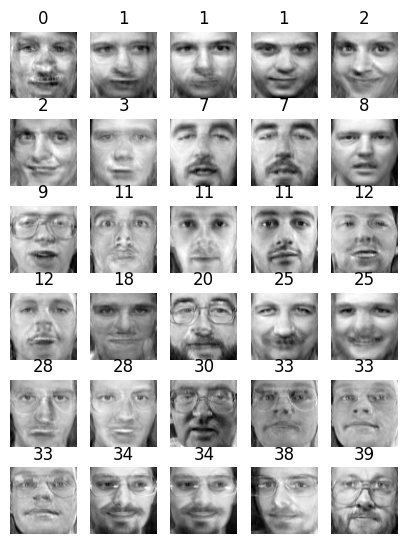

In [13]:
import matplotlib.pyplot as plt

def plot_faces(faces, labels, n_cols=5):
    # ---- fill here: reshape each face to 64×64 (original Olivetti resolution)
    faces = faces.reshape((-1, 64, 64))

    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))

    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)

    plt.show()


# 3. Visualize the generated faces
plot_faces(generated_faces, y_gen_faces, n_cols=5)

In [ ]:
plot_faces(generated_faces, y_gen_faces)

## 3. Take the first 5 images of your dataset and create 15 changed images. The first five(changed) images must be rotated 90 degrees counterclockwise. The second five (changed) images must beflipped. The third five images must be darker than the original images (multiply their channels by 0.3.)

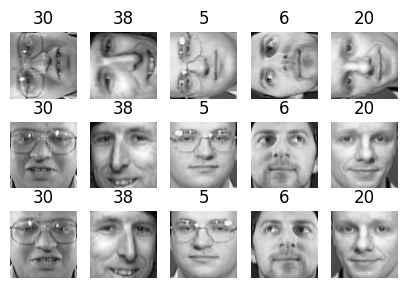

In [14]:
import numpy as np

#Q3

# 1. First 5 images: rotate 90 degrees counterclockwise
n_rotated = 5
rotated = np.rot90(X_train[:n_rotated].reshape(-1, 64, 64), k=1, axes=(1, 2))
rotated = rotated.reshape(-1, 64*64)
y_rotated = y_train[:n_rotated]

# 2. Next 5 images: flip horizontally
n_flipped = 5
flipped = np.flip(X_train[:n_flipped].reshape(-1, 64, 64), axis=2)
flipped = flipped.reshape(-1, 64*64)
y_flipped = y_train[:n_flipped]

# 3. Last 5 images: darken (multiply by 0.3)
n_darkened = 5
darkened = X_train[:n_darkened].copy()
darkened = darkened * 0.3
y_darkened = y_train[:n_darkened]

# Combine all 15 modified images
X_bad_faces = np.r_[rotated, flipped, darkened]
y_bad = np.concatenate([y_rotated, y_flipped, y_darkened])

# Plot the 15 changed images
plot_faces(X_bad_faces, y_bad)


## 4. Compute the log-likelihood of each sample. (you can use the gm methods.) Compare these log-likelihoods with the main data scores (maybe for the first 15 samples). Explain the results and describe how we use GMMs for anomaly detection.

Run the following code before next parts:D

In [15]:
X_bad_faces_pca = pca.transform(X_bad_faces)

In [16]:
bad_faces_ll = gm.score_samples(X_bad_faces_pca)

In [17]:
main_faces_ll = gm.score_samples(pca.transform(X_train[:15]))

In [18]:
print("Log-likelihoods for first 15 normal samples:\n", main_faces_ll)
print("\nLog-likelihoods for 15 modified samples:\n", bad_faces_ll)

Log-likelihoods for first 15 normal samples:
 [791.96173166 699.35868984 777.48108962 799.54003772 697.8939593
 791.6172433  728.22259466 697.89399827 684.33126028 756.55259708
 697.89396702 739.26668056 731.75901799 791.2412815  684.33130801]

Log-likelihoods for 15 modified samples:
 [-28987136.59701706 -26934315.11566255 -27108650.50603043
 -28275184.31511583 -24562525.36317211 -28475833.45230145
  -6594992.53322023  -9180613.12027206 -16169952.75013709
  -6182161.68278739 -82194872.90662563 -93600617.96082306
 -48653449.51183961 -59292267.75809658 -76789781.80920953]
